In [24]:
from joblib import Parallel, delayed
from tqdm.notebook import tqdm

import sys
import pickle
import numpy as np
import pandas as pd
import networkx as nx

In [2]:
np.random.seed(5)

In [3]:
sys.path.insert(0, "src")

from grn import grn

with open("../../grns/graph.647.gpickle", "rb") as f:
    G = pickle.load(f)

# Lets work with module 8

In [4]:
module_id = 8

genes_in_module = [
    gene
    for gene, group in G.groups.items()
    if group == module_id
]

genes_in_module = [int(g) for g in genes_in_module]

print(len(genes_in_module))
print(genes_in_module[:20])

195
[6, 11, 15, 17, 20, 28, 33, 46, 68, 69, 85, 91, 106, 111, 117, 121, 128, 130, 131, 137]


In [5]:
from itertools import combinations

all_pairs_module = list(combinations(genes_in_module, 2))

In [37]:
len(all_pairs_module)

18915

In [7]:
# 1. Reconstruct Single KO results
with np.load("../../../grn_files/module8_GRN#647_single_ko.npz") as data:
    single_expression = data["expression"]
    single_logfc = data["logfc"]
    single_convergence = data["convergence"]

# 2. Reconstruct Double KO results
with np.load("../../../grn_files/module8_GRN#647_double_ko.npz") as data:
    double_expression = data["expression"]
    double_logfc = data["logfc"]
    double_convergence = data["convergence"]

In [14]:
arr_all_pairs_module = np.array(
    all_pairs_module,
    dtype=np.int32
)

In [28]:
single_logfc = pd.DataFrame(single_logfc)
single_logfc.index = genes_in_module

In [39]:
single_a

,6,11,15,17,20,28,33,46,68,69,...,1895,1898,1905,1938,1973,1976,1977,1980,1984,1989
6,-0.040045,-0.377134,0.432108,-0.227520,-0.022561,0.359505,-0.786090,0.040109,0.125741,0.033500,...,0.525014,-0.168534,0.035488,-0.042131,-0.009826,0.038811,-0.009060,-0.014740,-0.007803,-0.237137
6,-0.040045,-0.377134,0.432108,-0.227520,-0.022561,0.359505,-0.786090,0.040109,0.125741,0.033500,...,0.525014,-0.168534,0.035488,-0.042131,-0.009826,0.038811,-0.009060,-0.014740,-0.007803,-0.237137
6,-0.040045,-0.377134,0.432108,-0.227520,-0.022561,0.359505,-0.786090,0.040109,0.125741,0.033500,...,0.525014,-0.168534,0.035488,-0.042131,-0.009826,0.038811,-0.009060,-0.014740,-0.007803,-0.237137
6,-0.040045,-0.377134,0.432108,-0.227520,-0.022561,0.359505,-0.786090,0.040109,0.125741,0.033500,...,0.525014,-0.168534,0.035488,-0.042131,-0.009826,0.038811,-0.009060,-0.014740,-0.007803,-0.237137
6,-0.040045,-0.377134,0.432108,-0.227520,-0.022561,0.359505,-0.786090,0.040109,0.125741,0.033500,...,0.525014,-0.168534,0.035488,-0.042131,-0.009826,0.038811,-0.009060,-0.014740,-0.007803,-0.237137
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1977,-0.000031,0.000017,-0.000250,0.000051,-0.000003,0.000068,0.000100,-0.000167,0.000005,-0.000019,...,0.000120,-0.000028,0.000006,-0.000007,0.000107,-0.000039,-0.000052,-0.000080,-0.000098,0.000025
1977,-0.000031,0.000017,-0.000250,0.000051,-0.000003,0.000068,0.000100,-0.000167,0.000005,-0.000019,...,0.000120,-0.000028,0.000006,-0.000007,0.000107,-0.000039,-0.000052,-0.000080,-0.000098,0.000025
1980,-0.000030,-0.000171,-0.000096,0.000035,0.000020,0.000004,-0.000090,-0.000083,0.000047,-0.000086,...,0.000103,-0.000022,-0.000038,-0.000035,0.000060,-0.000036,0.000067,-0.000013,-0.000079,-0.000024
1980,-0.000030,-0.000171,-0.000096,0.000035,0.000020,0.000004,-0.000090,-0.000083,0.000047,-0.000086,...,0.000103,-0.000022,-0.000038,-0.000035,0.000060,-0.000036,0.000067,-0.000013,-0.000079,-0.000024


In [40]:
single_a = single_logfc.loc[arr_all_pairs_module[:, 0], genes_in_module]
single_b = single_logfc.loc[arr_all_pairs_module[:, 1], genes_in_module]

expected_additive = single_a.values + single_b.values

interaction_residuals = double_logfc[:, genes_in_module] - expected_additive

print("double KO:", double_logfc.shape)
print("additive expectation:", expected_additive.shape)
print("interaction residuals:", interaction_residuals.shape)

double KO: (18915, 2000)
additive expectation: (18915, 195)
interaction residuals: (18915, 195)


In [41]:
errors = interaction_residuals.ravel()

# Just in case a simulation produced zero expression and therefore
# an infinite logFC:
errors = errors[np.isfinite(errors)]

print("Number of residuals:", len(errors))
print("Mean:", errors.mean())
print("SD:", errors.std())

print("Quantiles:")
print(
    np.quantile(
        errors,
        [0, 0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 0.999, 1]
    )
)

Number of residuals: 3688425
Mean: 1.6327265e-05
SD: 0.0133652575
Quantiles:
[-2.37337017e+00 -9.32658929e-02 -8.31164122e-03 -4.84227389e-04
 -3.71912574e-06  4.68811393e-04  8.35720137e-03  9.73205566e-02
  2.48206830e+00]


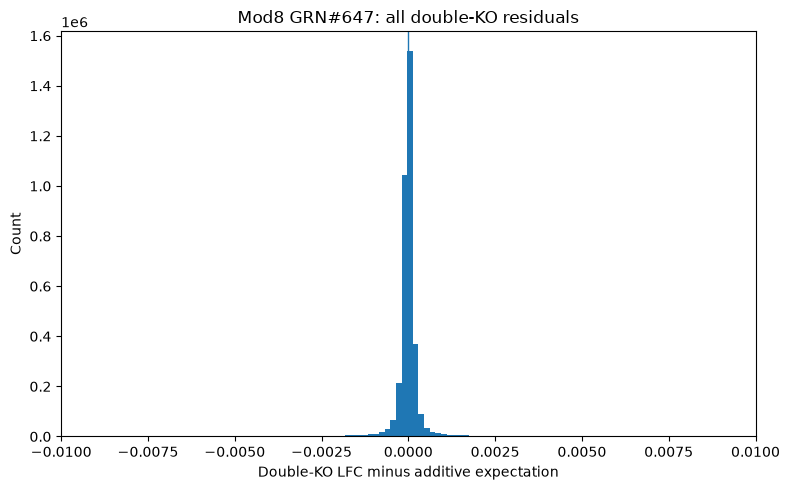

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    errors,
    bins=30000
)

plt.axvline(0, linewidth=1)

plt.xlim(-0.01, 0.01)

plt.xlabel("Double-KO LFC minus additive expectation")
plt.ylabel("Count")
plt.title("Mod8 GRN#647: all double-KO residuals")

plt.tight_layout()
plt.show()

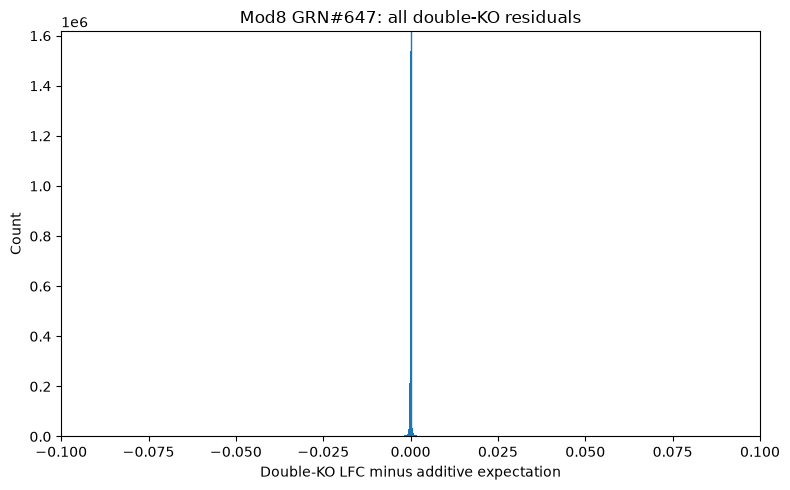

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    errors,
    bins=30000
)

plt.axvline(0, linewidth=1)

plt.xlim(-0.1, 0.1)

plt.xlabel("Double-KO LFC minus additive expectation")
plt.ylabel("Count")
plt.title("Mod8 GRN#647: all double-KO residuals")

plt.tight_layout()
plt.show()

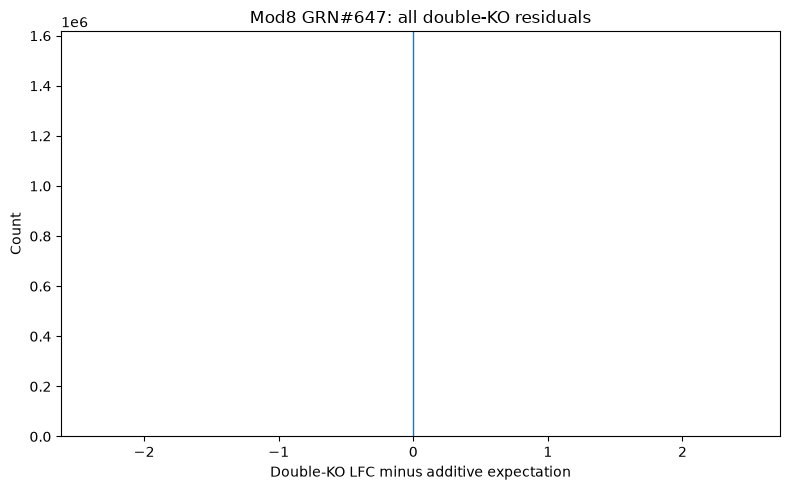

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    errors,
    bins=30000
)

plt.axvline(0, linewidth=1)

#plt.xlim(-0.1, 0.1)

plt.xlabel("Double-KO LFC minus additive expectation")
plt.ylabel("Count")
plt.title("Mod8 GRN#647: all double-KO residuals")

plt.tight_layout()
plt.show()